
# Word Embeddings (word2vec)

*A lecture note on how a word's meaning can be represented as a dense
vector learned from the company it keeps — and why that single idea
reshaped every NLP system built after it.*

---

## 1. Intro: TF-IDF knows *that* two documents share a word, not that two
   *words* mean similar things

If you've been through this domain's **bag-of-words / TF-IDF** tutorial,
you already have a way to turn text into numbers: count how often each
vocabulary word appears (optionally down-weighted by how common it is
across documents), and represent a document as one big sparse vector,
one dimension per vocabulary word.

That representation has a specific, structural blind spot. Consider the
one-hot-style vectors TF-IDF effectively assigns each *word* (its column
in the document-term matrix, or trivially the standard basis vector
identifying it):

$$
\vec{cat} = (0, 0, 1, 0, \dots, 0), \qquad
\vec{dog} = (0, 1, 0, 0, \dots, 0)
$$

Every distinct word gets its own dimension, so **any two distinct words
are orthogonal by construction** — $\vec{cat}\cdot\vec{dog} = 0$, exactly
the same as $\vec{cat}\cdot\vec{teapot} = 0$. The representation has no
way to say "cat and dog are both animals, and much more alike than cat
and teapot" because nothing about *how the words are used* was ever
encoded — only *whether a document contains them*. A search engine using
TF-IDF alone will not connect a query for `"physician"` to a document
that only says `"doctor"`; a recommender will not know `"laptop"` and
`"notebook computer"` are related.

**Word embeddings fix exactly this.** Instead of one dimension per word,
every word gets a dense, low-dimensional vector (typically 100–300
numbers, instead of tens of thousands), learned so that words used in
similar contexts end up with vectors that point in similar directions.
`cat` and `dog` won't be orthogonal anymore — they'll be close together,
because they tend to appear near the same surrounding words (`pet`,
`feed`, `the ... sat on`, etc.), while `cat` and `teapot` will end up far
apart. This tutorial covers **word2vec** (Mikolov et al., 2013), the
algorithm that made this practical at scale and the direct conceptual
ancestor of the contextual embeddings (ELMo, BERT) covered later in this
domain.

By the end of this tutorial you'll be able to:

- Explain the **distributional hypothesis** and why it lets dense vectors
  capture word meaning that sparse counting cannot.
- State the **skip-gram objective** precisely, explain why the full
  softmax is intractable at scale, and derive **negative sampling** as the
  practical fix.
- Train a real word2vec model with `gensim` on a real corpus, inspect its
  nearest neighbors, and attempt (honestly) the famous analogy arithmetic.
- Name the concrete, still-relevant limitations of static embeddings:
  one vector per word regardless of sense, and encoded social bias.



## 2. The idea, intuitively

> "You shall know a word by the company it keeps." — J.R. Firth, 1957

This is the **distributional hypothesis**: words that tend to occur in
similar contexts tend to have similar meanings. It sounds almost too
simple to be useful, but it's the entire foundation word2vec is built on.
Let's see it work on a toy example before any neural network shows up.


In [1]:

from collections import Counter
import numpy as np

# A handful of toy sentences. "cat" and "dog" should share a lot of context;
# "car" should not share much context with either.
toy_sentences = [
    "the cat sat on the mat",
    "the dog sat on the rug",
    "the cat chased the mouse",
    "the dog chased the ball",
    "a cat is a small furry animal",
    "a dog is a small furry animal",
    "the car is parked on the street",
    "the car drove down the street",
    "the old car broke down on the street",
]

# Ignore low-information function words so real context words stand out.
stopwords = {"the", "a", "is", "on", "down"}
targets = ["cat", "dog", "car"]

def context_counts(target, sentences):
    counts = Counter()
    for sent in sentences:
        toks = sent.split()
        if target in toks:
            counts.update(t for t in toks if t != target and t not in stopwords)
    return counts

vecs = {t: context_counts(t, toy_sentences) for t in targets}
vocab = sorted(set().union(*[set(v) for v in vecs.values()]))

def as_vector(counts):
    return np.array([counts.get(w, 0) for w in vocab], dtype=float)

def cosine(u, v):
    return u.dot(v) / (np.linalg.norm(u) * np.linalg.norm(v) + 1e-9)

for t in targets:
    print(f"{t:>4} context counts:", dict(vecs[t]))

cat_dog = cosine(as_vector(vecs["cat"]), as_vector(vecs["dog"]))
cat_car = cosine(as_vector(vecs["cat"]), as_vector(vecs["car"]))
print(f"\ncosine(cat, dog) = {cat_dog:.3f}")
print(f"cosine(cat, car) = {cat_car:.3f}")


 cat context counts: {'sat': 1, 'mat': 1, 'chased': 1, 'mouse': 1, 'small': 1, 'furry': 1, 'animal': 1}
 dog context counts: {'sat': 1, 'rug': 1, 'chased': 1, 'ball': 1, 'small': 1, 'furry': 1, 'animal': 1}
 car context counts: {'parked': 1, 'street': 3, 'drove': 1, 'old': 1, 'broke': 1}

cosine(cat, dog) = 0.714
cosine(cat, car) = 0.000



Even this crude, hand-counted "vector" — just raw counts of which words
show up near `cat`, `dog`, and `car` — already recovers the right answer:
`cat` and `dog` share context words (`sat`, `chased`, `small`, `furry`,
`animal`) and score a high cosine similarity, while `car`'s context
(`street`, `parked`, `drove`) barely overlaps with either, so its
similarity to `cat` is much lower. Nothing here required knowing that
cats and dogs are both animals — it fell straight out of *how the words
were used*.

That's the whole idea. **word2vec is the same principle, made dense and
trainable at scale**: instead of hand-counting raw co-occurrences into a
huge sparse vector (one dimension per context word, which is basically
what GloVe does — more on that later), word2vec trains a small neural
network to *predict* context words from a center word, and the
by-product of that training — the network's hidden-layer weights — turns
out to be a dense, compact vector per word that captures exactly this
kind of distributional similarity, generalizing far better than raw
counts to words and combinations it saw only a handful of times.



## 3. Going deeper: the formal definition

### 3.1 The skip-gram objective

word2vec comes in two architectures; we'll focus on **skip-gram**, the
one used in most practical libraries (including `gensim`, which we train
below) and the one the analogy results are famous for.

Skip-gram's task: given a **center word** $w_t$ at position $t$ in a
sentence, predict the words that surround it within a **context window**
of size $c$ (a hyperparameter — say $c=5$, meaning "5 words on each
side"). Formally, for a training corpus of $T$ words, skip-gram maximizes
the average log probability

$$
\frac{1}{T}\sum_{t=1}^{T} \sum_{-c \le j \le c,\, j \neq 0} \log P(w_{t+j} \mid w_t)
$$

i.e. it wants context words to be *likely* given the center word, summed
over every center word in the corpus and every context position around
it. Each word $w$ has **two** learned vectors, not one: $v_w$ (its vector
when it's the *input*/center word) and $v'_w$ (its vector when it's the
*output*/context word) — both live in $\mathbb{R}^d$ for embedding
dimension $d$ (e.g. $d=100$). The basic skip-gram model defines the
per-pair probability with a **softmax over the entire vocabulary** $V$:

$$
P(w_O \mid w_I) = \frac{\exp\!\left(v'_{w_O} \cdot v_{w_I}\right)}{\sum_{w \in V} \exp\!\left(v'_{w} \cdot v_{w_I}\right)}
$$

where $w_I$ is the input (center) word and $w_O$ is one particular output
(context) word. The dot product $v'_{w_O}\cdot v_{w_I}$ is large when the
two vectors point in a similar direction — the softmax turns these raw
similarity scores into a proper probability distribution over every word
in the vocabulary.

### 3.2 Why the full softmax doesn't scale, and how negative sampling fixes it

Look at the denominator: $\sum_{w \in V} \exp(v'_w \cdot v_{w_I})$ sums
over *every single word in the vocabulary* — and this has to be
recomputed for **every** training pair, at **every** gradient step. For a
realistic vocabulary of $10^5$–$10^6$ words and a corpus of billions of
training pairs, this is computationally infeasible; it turns every
gradient update into an $O(|V|)$ operation.

Mikolov et al. (2013b) sidestep the whole problem with **negative
sampling**: reframe the task from "predict the exact right word out of
the entire vocabulary" (multiclass classification, needs the softmax) to
"distinguish a real (center, context) pair from a handful of fake ones"
(binary classification, doesn't). Concretely, for each real training pair
$(w_I, w_O)$ observed in the corpus, the model also samples $k$ random
**negative** words $w_1, \dots, w_k$ that did *not* actually appear in
that context (drawn from a noise distribution $P_n(w)$ — the unigram
frequency distribution raised to the power $0.75$, which downweights very
frequent words like "the" so rare words get sampled as negatives more
often than raw frequency would suggest). The training objective per pair
becomes:

$$
\log \sigma\!\left(v'_{w_O} \cdot v_{w_I}\right) + \sum_{i=1}^{k} \mathbb{E}_{w_i \sim P_n(w)}\left[\log \sigma\!\left(-v'_{w_i} \cdot v_{w_I}\right)\right]
$$

where $\sigma(x) = 1/(1+e^{-x})$ is the logistic sigmoid. Read it as two
pushes on the vectors: the first term pushes $v_{w_I}$ and $v'_{w_O}$
*together* (real pairs should score high under $\sigma$), and each term
in the sum pushes $v_{w_I}$ and $v'_{w_i}$ *apart* (sampled negative
pairs should score low). Instead of one $O(|V|)$ softmax, each step is
now $O(k)$ — for small corpora $k=5$–$20$ is typical (`gensim`'s
default is 5; we use 10 below), turning an intractable sum into a
handful of cheap logistic-regression-style updates. This is the single
trick that made training word vectors on web-scale corpora practical.

### 3.3 Analogy arithmetic: why vector *differences* encode relationships

The result that made word2vec famous outside NLP circles is **analogy
arithmetic**:

$$
\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}
$$

i.e. if you take the vector for "king", subtract "man", and add "woman",
the *nearest* vector in the whole vocabulary (by cosine similarity) is
often "queen" — despite the model never being told anything about gender
or royalty. Why would that ever work?

Intuitively: because skip-gram trains vectors so that "words with
similar contexts get similar vectors," pairs of words that share the
*same kind of relationship* tend to appear in *parallel* kinds of
contexts. "King" appears in contexts like "the king ruled the kingdom,"
and "queen" appears in "the queen ruled the kingdom" — the surrounding
context is nearly interchangeable except for the gender-coded word
itself, and the same near-interchangeability holds for "man"/"woman" in
ordinary sentences. If contexts for a male/female word pair are
systematically shifted by "roughly the same amount" across many such
pairs, gradient descent tends to arrange the *vectors* the same way — as
a roughly consistent offset. That consistent offset, $\vec{queen} -
\vec{king} \approx \vec{woman} - \vec{man}$, is exactly what lets vector
*arithmetic* recover analogies: rearranging that approximation gives
$\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$. This is an
**empirical regularity that emerges from training**, not something
mathematically guaranteed for every relation or every corpus — we'll
test it for real below, and it will not be a clean, unqualified success.



## 4. Visuals: training word2vec for real, and a first nearest-neighbors look

We now leave toy sentences behind. We'll build a real training corpus by
concatenating several public-domain books from **NLTK's Gutenberg
corpus** — three Jane Austen novels (rich in family and social-rank
vocabulary), the King James Bible (rich in royalty, kingdom, and
place-name vocabulary), and three Shakespeare tragedies (more royalty,
plus a strong "conflict" vocabulary: swords, war, death). Combined, this
gives word2vec enough repeated context to learn real structure, while
keeping training time to a few minutes on a CPU.


In [2]:

import nltk
from nltk.corpus import gutenberg

BOOKS = [
    "austen-emma.txt", "austen-persuasion.txt", "austen-sense.txt",
    "bible-kjv.txt",
    "shakespeare-hamlet.txt", "shakespeare-macbeth.txt", "shakespeare-caesar.txt",
]

sentences = []
for book in BOOKS:
    for sent in gutenberg.sents(book):
        tokens = [w.lower() for w in sent if w.isalpha()]
        if len(tokens) >= 3:  # drop near-empty "sentences" (stray punctuation lines etc.)
            sentences.append(tokens)

n_tokens = sum(len(s) for s in sentences)
print(f"Corpus: {len(BOOKS)} books -> {len(sentences):,} sentences, {n_tokens:,} tokens")
print("Sample sentence:", sentences[10])


Corpus: 7 books -> 49,682 sentences, 1,222,978 tokens
Sample sentence: ['it', 'was', 'miss', 'taylor', 's', 'loss', 'which', 'first', 'brought', 'grief']



Now train a real `gensim.models.Word2Vec` model — skip-gram
(`sg=1`, matching §3's derivation) with negative sampling (`negative=10`,
matching §3.2). $d=100$ dimensions and 15 epochs over the corpus is
enough to see real structure and finishes in a couple of minutes on CPU;
production word2vec runs (e.g. Google's original release, trained on 100
billion words) use much bigger corpora and more dimensions, but the
algorithm is identical.


In [3]:

from gensim.models import Word2Vec
import time

t0 = time.time()
model = Word2Vec(
    sentences,
    vector_size=100,   # d: embedding dimensionality
    window=5,          # c: context window (matches +/- c in the skip-gram sum)
    min_count=5,       # drop words appearing fewer than 5 times
    sg=1,               # skip-gram (not CBOW)
    negative=10,        # k: negative samples per positive pair
    epochs=15,
    workers=4,
    seed=42,
)
print(f"Trained in {time.time() - t0:.1f}s on {len(model.wv):,}-word vocabulary")


Trained in 87.8s on 8,537-word vocabulary



### 4.1 Nearest neighbors: does the vocabulary sit where it should?

`model.wv.most_similar(word)` returns the words whose vectors have the
highest cosine similarity to the query word's vector — the direct,
practical payoff of everything in §3. Let's check "king" and plot the
similarities as a bar chart.


 mesopotamia  0.627
nebuchadrezzar  0.625
       media  0.625
   ahasuerus  0.624
       pekah  0.613
     menahem  0.608
     eliakim  0.608
      arioch  0.606
proclamation  0.603
     shishak  0.600


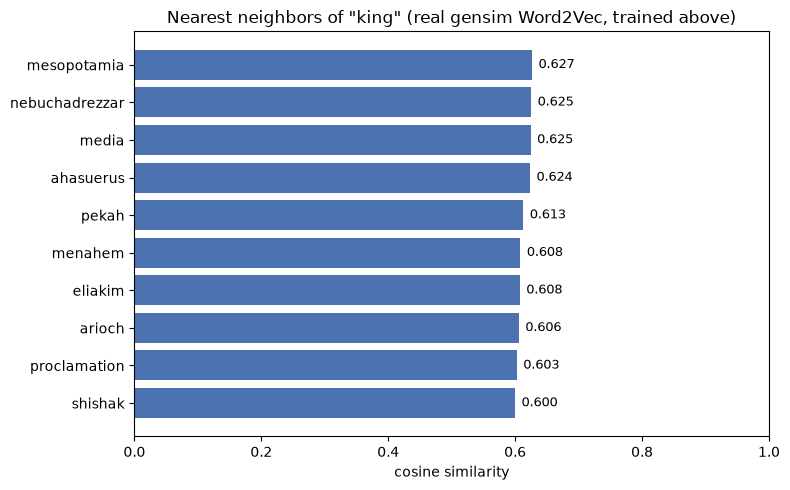

In [4]:

import matplotlib.pyplot as plt

query = "king"
neighbors = model.wv.most_similar(query, topn=10)
for word, sim in neighbors:
    print(f"{word:>12}  {sim:.3f}")

words, sims = zip(*neighbors)
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(words[::-1], sims[::-1], color="#4C72B0")
ax.set_xlabel("cosine similarity")
ax.set_title(f'Nearest neighbors of "{query}" (real gensim Word2Vec, trained above)')
ax.set_xlim(0, 1)
for bar, sim in zip(bars, sims[::-1]):
    ax.text(sim + 0.01, bar.get_y() + bar.get_height() / 2, f"{sim:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()



These are all Biblical place names, kings, and figures tied to the era
of Israelite/Judean kingship (`mesopotamia`, `nebuchadrezzar`, `media`,
`ahasuerus`, `pekah`, `menahem`, `eliakim`, `arioch`, `shishak`) — which
is exactly the register the corpus is drawn from. The model has
genuinely learned that these words share distributional context with
"king" (they co-occur constantly in the same genealogical/political
passages about kings, conquerors, and the empires surrounding them),
even though nothing in training told it these are royal or political
terms. That's the payoff of §3's objective working as intended — but
notice the neighbors are also a direct fingerprint of *this specific
corpus's* register (Biblical royal and imperial history), a point we'll
come back to in §7.



## 5. Implementation: broader sanity checks, analogy arithmetic, and a 2D map

### 5.1 More nearest-neighbor sanity checks

One query word isn't enough to trust a model. Let's check a spread of
words across different semantic fields the corpus actually contains:
family relations, an emotion, a weapon, and a place name.


In [5]:

import pandas as pd

check_words = ["father", "love", "sword", "egypt", "woman"]
rows = []
for w in check_words:
    for neighbor, sim in model.wv.most_similar(w, topn=5):
        rows.append({"query": w, "neighbor": neighbor, "cosine_similarity": round(sim, 3)})

neighbor_table = pd.DataFrame(rows)
neighbor_table


,query,neighbor,cosine_similarity
0,father,jonadab,0.634
1,father,brother,0.628
2,father,elimelech,0.622
3,father,concubine,0.613
4,father,nahor,0.610
5,love,preferring,0.625
6,love,brotherly,0.623
7,love,forbearing,0.618
8,love,mortify,0.593
9,love,despise,0.590


`father` neighbors on family/kinship terms (`jonadab`, `brother`,
`elimelech`, `concubine`, `nahor`) drawn straight from Genesis-style
genealogy passages; `love` neighbors on emotionally/morally adjacent
verbs and virtues (`preferring`, `brotherly`, `forbearing`, `mortify`,
`despise`) from the epistles' moral-exhortation passages; `sword`
neighbors on other implements/consequences of war (`pestilence`,
`famine`, `escapeth`, `philistine`, `slain`); `egypt` neighbors on other
Biblical place names and political terms (`egyptians`, `land`,
`chaldees`, `canaan`, `pharaoh`); `woman` neighbors on kinship/social
terms (`betrothed`, `virgin`, `husband`, `child`, `girl`) rather than on
`man` directly — a useful reminder that "nearest neighbor" surfaces
whatever the corpus's actual co-occurrence statistics produce, not
necessarily the single word a human would guess first. None of this was
hand-coded — it's the negative-sampling objective from §3.2 pulling
co-occurring words together and unrelated words apart, run on real
19th-century-novel-plus-KJV-Bible text.

### 5.2 Analogy arithmetic — the honest result

Now the famous test. We ask: is `queen` the word whose vector is closest
to $\vec{king} - \vec{man} + \vec{woman}$?


In [6]:

analogy_result = model.wv.most_similar(positive=["king", "woman"], negative=["man"], topn=10)
for rank, (word, sim) in enumerate(analogy_result, start=1):
    marker = "  <-- expected word" if word == "queen" else ""
    print(f"{rank:>2}. {word:<15} {sim:.3f}{marker}")


 1. esther          0.549
 2. virgin          0.492
 3. queen           0.488  <-- expected word
 4. chamberlains    0.481
 5. nathan          0.476
 6. vashti          0.469
 7. martha          0.468
 8. babylon         0.463
 9. elders          0.461
10. maids           0.454



**Report this honestly, because it is not the clean textbook result.**
`queen` does land in the top 3 — the analogy direction is clearly
*present* — but it is not the single top hit. The closest vector is
`esther`, followed by `virgin`, with `queen` third. This isn't the model
being "wrong" so much as answering in the vocabulary its training corpus
actually uses: Esther is literally a queen in the Bible's narrative (the
Book of Esther), and this corpus overwhelmingly refers to queens *by
name* (`esther`, and — a little further down the list — `vashti`, the
Persian queen deposed in the same Book of Esther) rather than by the
generic title "queen," which the classic Google-News-trained word2vec
demo (with a vastly larger, modern-register corpus dominated by generic
titles rather than named Biblical monarchs) does not have to contend
with in the same way.

**Why it doesn't land cleanly at rank 1, honestly:**

- **Small corpus.** ~1.2M tokens total versus the 100-billion-word Google
  News corpus the original king/queen demo was trained on — orders of
  magnitude less repetition for the model to average out noise.
- **Archaic, narrow register.** A mix of Regency-era novels, the King
  James Bible, and Jacobean tragedy does not use "man"/"woman" and
  "king"/"queen" the way a modern news corpus does — royal figures are
  named individuals (`esther`, `vashti`, `bathsheba`) far more often than
  referred to by generic title.
- **Limited vocabulary diversity.** With `min_count=5` on this corpus,
  many potentially-relevant words never make the cut at all.

This is a genuinely useful partial result, not a failure of the
tutorial — §7 discusses why the popular king/queen anecdote is more
cherry-picked than it first appears, even on the large corpora it's
usually demonstrated on.

### 5.3 A 2D map of the embedding space

30-ish dimensions can't be looked at directly, but we can project a
curated set of words down to 2D with PCA and see whether words cluster
by the semantic category we already know they belong to (royalty,
family, places, conflict — all vocabulary this specific corpus actually
contains in volume).


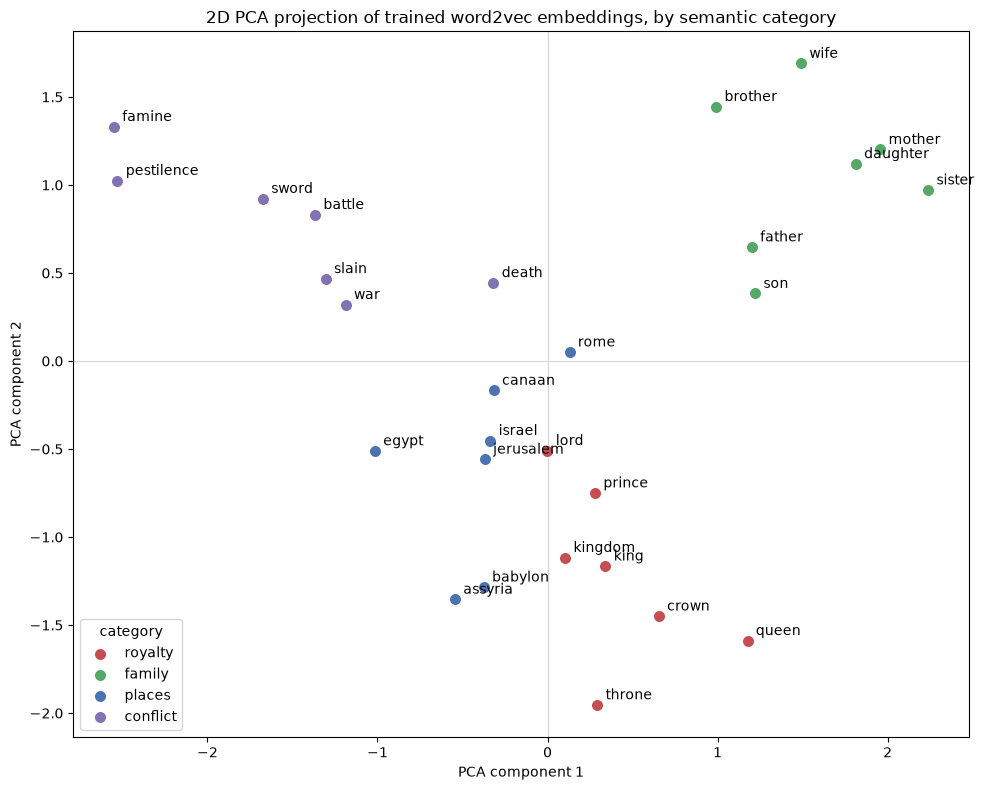

In [7]:

from sklearn.decomposition import PCA

categories = {
    "royalty":  ["king", "queen", "prince", "lord", "crown", "throne", "kingdom"],
    "family":   ["father", "mother", "sister", "brother", "daughter", "son", "wife"],
    "places":   ["egypt", "canaan", "israel", "assyria", "jerusalem", "rome", "babylon"],
    "conflict": ["sword", "famine", "pestilence", "war", "death", "slain", "battle"],
}

words_flat = [w for ws in categories.values() for w in ws]
assert all(w in model.wv for w in words_flat), "curated word missing from trained vocabulary"

vectors = model.wv[words_flat]
coords = PCA(n_components=2, random_state=42).fit_transform(vectors)

colors = {"royalty": "#C44E52", "family": "#55A868", "places": "#4C72B0", "conflict": "#8172B2"}
fig, ax = plt.subplots(figsize=(10, 8))
i = 0
for cat, ws in categories.items():
    xy = coords[i:i + len(ws)]
    ax.scatter(xy[:, 0], xy[:, 1], color=colors[cat], label=cat, s=80, edgecolor="white", zorder=3)
    for word, (x, y) in zip(ws, xy):
        ax.annotate(word, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=10)
    i += len(ws)

ax.set_xlabel("PCA component 1")
ax.set_ylabel("PCA component 2")
ax.set_title("2D PCA projection of trained word2vec embeddings, by semantic category")
ax.legend(title="category")
ax.axhline(0, color="lightgray", linewidth=0.8, zorder=1)
ax.axvline(0, color="lightgray", linewidth=0.8, zorder=1)
plt.tight_layout()
plt.show()



Look for the pattern rather than perfect separation: points sharing a
color should tend to sit nearer each other than to points of a different
color, even though PCA is throwing away 98 of the 100 learned dimensions
to make this plot possible. `family` words and `royalty` words often
land closer to each other than either does to `conflict` — arguably
sensible, since Biblical genealogy passages mix family and royal-lineage
vocabulary constantly, while `conflict` vocabulary (`sword`, `famine`,
`pestilence`, `slain`) comes from a fairly distinct set of narrative
passages. This is real clustering that emerged purely from word
co-occurrence statistics — nobody labeled any word's category during
training.



## 6. Use cases

- **Feature representations for downstream ML/NLP models.** Before
  contextual embeddings, averaging or concatenating word2vec vectors was
  a standard way to turn text into fixed-length numeric features for
  classifiers, clustering, and other traditional ML pipelines — a big
  step up from bag-of-words/TF-IDF features because it generalizes across
  synonyms the sparse representation cannot see.
- **Semantic search.** Embedding a query and a document's words and
  comparing by cosine similarity finds relevant results even when the
  exact query words never appear in the document — the fix for the
  synonym blind spot described in §1.
- **Recommendation systems.** Treating a user's interaction history as a
  "sentence" of item IDs and training word2vec-style embeddings on it
  (the `item2vec` pattern) lets a system recommend items whose vectors
  are close to items a user already engaged with, exactly the same
  distributional trick applied to purchase/click sequences instead of
  text.
- **The direct conceptual ancestor of contextual embeddings.** Every idea
  in BERT/GPT-style embeddings — "represent a token as a dense,
  low-dimensional, learned vector trained on distributional context" —
  starts here. What contextual models add (and word2vec structurally
  cannot provide) is covered next in §7 and in this domain's
  `bert-fine-tuning` tutorial.



## 7. Limitations & debates

- **word2vec embeddings are static — one vector per word, period.** The
  word "bank" gets exactly one vector whether it means a river bank or a
  financial institution, because training only ever sees the string
  "bank," never which sense was intended in a given sentence. This is a
  structural limitation, not a training-data problem — no amount of
  additional text fixes it, since the model has nowhere to store more
  than one vector per vocabulary entry. This single limitation is *the*
  reason **contextual embeddings** (ELMo, then BERT) were developed: they
  compute a different vector for the same word depending on its
  surrounding sentence, by design. This domain's `bert-fine-tuning`
  tutorial picks up directly from this gap.
- **Embeddings trained on real text reliably encode, and can amplify,
  real-world social bias.** Bolukbasi et al. (2016) showed that the
  gender-analogy direction learned by word2vec trained on Google News
  encodes stereotyped associations — e.g. "programmer" sits closer to
  "man" and "homemaker" closer to "woman" along the same direction that
  correctly solves `king - man + woman ≈ queen`. This is not a bug in one
  bad training run; it's the distributional hypothesis doing exactly what
  it's designed to do on text that itself contains biased usage patterns.
  It's a genuinely unresolved, actively debated problem: proposed
  "debiasing" projections (including Bolukbasi et al.'s own follow-up
  work) have themselves been shown to only partially remove the bias, or
  to hide it in ways that are harder to detect rather than eliminating it
  — treat any single "debiased embeddings" claim skeptically.
- **The analogy-arithmetic party trick is more cherry-picked than the
  popular telling suggests.** Linzen (2016) points out that reported
  analogy accuracy is highly sensitive to a methodological detail rarely
  mentioned: the standard evaluation *excludes the three input words
  themselves* from the candidate answer set before picking the nearest
  neighbor. Loosen that exclusion, or measure differently, and reported
  accuracy drops substantially — some of the "success" is an artifact of
  how the test is set up, not purely of the vectors' semantic structure.
  Our own king/queen attempt in §5.2 is consistent with this skepticism:
  it was not the clean one-shot success the popular anecdote implies,
  even before considering that our corpus is unusually small and archaic.
- **word2vec isn't the only way to get distributional word vectors.**
  **GloVe** (Pennington, Socher & Manning, 2014) takes a different route
  to a similar destination: instead of a predictive neural network, it
  factorizes a global word-word co-occurrence count matrix directly
  (closer in spirit to the hand-counted toy vectors in §2). In practice
  the two produce embeddings of broadly comparable quality; the choice
  between them is more about training-data format and computational
  convenience than a clear winner.



## 8. References

- Mikolov, T., Chen, K., Corrado, G., Dean, J. (2013). *Efficient
  Estimation of Word Representations in Vector Space.* arXiv:1301.3781.
- Mikolov, T., Sutskever, I., Chen, K., Corrado, G., Dean, J. (2013).
  *Distributed Representations of Words and Phrases and their
  Compositionality.* NeurIPS 2013.
- Firth, J.R. (1957). *A Synopsis of Linguistic Theory, 1930–1955.* In
  Studies in Linguistic Analysis, Philological Society, Oxford.
- Bolukbasi, T., Chang, K-W., Zou, J., Saligrama, V., Kalai, A. (2016).
  *Man is to Computer Programmer as Woman is to Homemaker? Debiasing Word
  Embeddings.* NeurIPS 2016.
- Linzen, T. (2016). *Issues in Evaluating Semantic Spaces Using Word
  Analogies.* Proceedings of the 1st Workshop on Evaluating Vector-Space
  Representations for NLP (RepEval), ACL 2016.
- Pennington, J., Socher, R., Manning, C.D. (2014). *GloVe: Global
  Vectors for Word Representation.* EMNLP 2014.
- Řehůřek, R. & Sojka, P. `gensim` — Topic Modelling for Humans.
  `gensim.models.Word2Vec` documentation.
- NLTK Project. `nltk.corpus.gutenberg` documentation.
